In [2]:
from typing import TypedDict, List, Dict, Any

class AgentState(TypedDict):
    file_path: str                 # Path to the raw CSV
    output_file_path: str          # The clean data destination
    df_summary: str                # Dynamic string representation of df.info() and df.describe()
    anomalies: List[str]           # List of issues detected by the Analyst
    cleaning_code: str             # The Python script written by the Engineer
    execution_errors: str          # Any traceback errors from running the code
    validation_passed: bool        # Flag from the Validator node
    iteration_count: int           # Safety brake to prevent infinite loops

In [3]:
import pandas as pd

def profile_data_node(state: AgentState) -> Dict[str, Any]:
    df = pd.read_csv(state["file_path"])
    
    # Capture structural metadata safely
    buffer = []
    buffer.append(f"Columns and Types:\n{df.dtypes.to_string()}")
    buffer.append(f"\nMissing Values:\n{df.isnull().sum().to_string()}")
    buffer.append(f"\nStatistical Summary:\n{df.describe(include='all').to_string()}")
    
    # Take a tiny, safe sample snippet
    buffer.append(f"\nFirst 3 rows sample:\n{df.head(3).to_string()}")
    
    return {
        "df_summary": "\n".join(buffer),
        "iteration_count": state.get("iteration_count", 0) + 1
    }

In [36]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

def analyst_agent_node(state: AgentState) -> Dict[str, Any]:
    llm = ChatGroq(model="llama-3.1-8b-instant")
    
    prompt = f"""
    You are a Staff Data Quality Analyst at a Fortune 500 company. 
    Your job is to deeply profile the provided dataset summary and identify all structural, logical, and typing anomalies.
    
    DATASET SUMMARY:
    {state["df_summary"]}
    
    Analyze the data against the following Enterprise Quality Checklist. Identify issues and prescribe safe solutions:
    
    1. STRUCTURAL ISSUES: Look for leading/trailing whitespaces in headers or string values.
    2. TIDY DATA PRINCIPLES: Identify compound columns (e.g., "Department_Region" containing "Sales-Texas") and prescribe splitting them using the delimiter.
    3. IDENTIFIERS VS NUMERICS (CRITICAL): Identify columns like "Phone", "Employee_ID", or "Zip". These are IDENTIFIERS, not math variables. If Phone numbers show negative values or scientific notation, it is integer overflow corruption. Prescribe setting negative identifiers to NaN, and treating the column entirely as strings.
    4. MISSING DATA: Prescribe imputation (median for numeric, "Unknown" for categories). NEVER drop rows.
    5. LOGICAL ERRORS: Look for impossible numeric values (negative age). Prescribe nullifying (NaN) irrecoverable corruption.
    6. VALID OUTLIERS: Look at min/max vs mean. Prescribe capping valid outliers (e.g., Salary) using the IQR method.
    7. CARDINALITY: Prescribe standardizing categorical text (lowercase, strip whitespace).
    
    OUTPUT FORMAT: Provide a highly structured, bulleted list of specific issues found and exact instructions on how to fix them.
    """
    
    response = llm.invoke([HumanMessage(content=prompt)])
    
    # Parse whether to route to finish or keep cleaning
    anomalies = [response.content] if "DATA_CLEAN" not in response.content else []
    
    return {"anomalies": anomalies}

In [37]:
def engineer_agent_node(state: AgentState) -> Dict[str, Any]:
    llm = ChatGroq(model="llama-3.1-8b-instant")
    
    error_context = f"\nCRITICAL: Your previous code failed with this error: {state['execution_errors']}. Correct your logic." if state.get("execution_errors") else ""

    prompt = f"""
    You are a Senior Data Engineer. Write a robust, fault-tolerant Python function `clean_dataframe(df: pd.DataFrame) -> pd.DataFrame`.
    
    ANALYST PLAN:
    {state["anomalies"]}
    {error_context}
    
    DEFENSIVE CODING MANDATES (CRITICAL):
    1. COLUMN SANITIZATION: First, run `df.columns = df.columns.str.strip()`.
    2. SAFE CHECKS: Always check `if 'ColName' in df.columns:` before modifying any column.
    3. THE IDENTIFIER RULE (NO INT64 OVERFLOWS): Phone numbers, IDs, and Zip codes MUST NOT be cast to integers. 
       - To clean 'Phone': coerce to numeric `errors='coerce'`, set `df.loc[df['Phone'] < 0, 'Phone'] = np.nan`, then safely cast to string using `astype(str).str.replace('\.0', '', regex=True)`. Replace "nan" strings with `np.nan`.
    4. SAFE COLUMN SPLITTING: Use `df[['New1', 'New2']] = df['Old'].str.split('-', expand=True)`. Drop the old column after splitting.
    5. NEVER DROP ROWS: Use `.fillna()` to impute data. Do not use `.dropna()`.
    6. SAFE NUMERIC CASTING: Use `pd.to_numeric(df['col'], errors='coerce')` for actual math variables (Salary, Age).
    7. NO INPLACE: Reassign variables instead of using `inplace=True`.
    8. SAFE STRING FORMATTING (CRITICAL): NEVER use `df.applymap()` or `df.map()`. To apply string methods like lower() or strip(), you MUST only target 'object' columns like this:
       `for col in df.select_dtypes(include=['object']).columns:`
           `df[col] = df[col].astype(str).str.lower().str.strip()`
           `df[col] = df[col].replace('nan', np.nan)`
    9. IMPORTS: Ensure `import pandas as pd` and `import numpy as np` are included inside your code block.
    
    Return ONLY valid, executable Python code wrapped in a single ```python ``` block. Do not add conversational text.
    """
    
    response = llm.invoke([HumanMessage(content=prompt)])
    # Extract code from Markdown blocks
    code = response.content.split("```python")[1].split("```")[0].strip()
    
    return {"cleaning_code": code}

In [38]:
import numpy as np
def execution_node(state: AgentState) -> Dict[str, Any]:
    # 1. Read from the RAW file
    df = pd.read_csv(state["file_path"])
    code = state["cleaning_code"]
    
    local_vars = {"df": df, "pd": pd, "np": np}
    try:
        exec(code, globals(), local_vars)
        clean_df = local_vars["clean_dataframe"](df)
        
        # 2. Save to the NEW file path
        clean_df.to_csv(state["output_file_path"], index=False)
        
        return {"execution_errors": "", "validation_passed": False}
    except Exception as e:
        import traceback
        return {"execution_errors": traceback.format_exc(), "validation_passed": False}

In [39]:
def route_after_analyst(state: AgentState):
    # If no anomalies were flagged, or we hit a circuit breaker loop count of 5 iterations
    if not state["anomalies"] or state["iteration_count"] >= 5:
        return "end"
    return "engineer"

def route_after_execution(state: AgentState):
    if state["execution_errors"]:
        return "engineer" # Loop straight back to engineer to fix code syntax
    return "profiler"     # Go back to profile the new data state and re-verify

In [40]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# Add all components as nodes
workflow.add_node("profiler", profile_data_node)
workflow.add_node("analyst", analyst_agent_node)
workflow.add_node("engineer", engineer_agent_node)
workflow.add_node("executor", execution_node)

# Set up the entry point and connections
workflow.set_entry_point("profiler")
workflow.add_edge("profiler", "analyst")

# Add conditional routing
workflow.add_conditional_edges(
    "analyst",
    route_after_analyst,
    {
        "engineer": "engineer",
        "end": END
    }
)

workflow.add_edge("engineer", "executor")

workflow.add_conditional_edges(
    "executor",
    route_after_execution,
    {
        "engineer": "engineer",
        "profiler": "profiler"
    }
)

# Compile into a runnable application
app = workflow.compile()

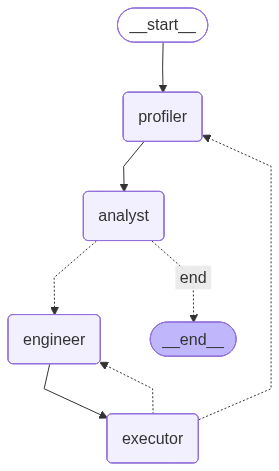

In [41]:
app

In [42]:
import os
from langchain_groq import ChatGroq

# 1. Set your OpenAI credential securely
os.environ["GROQ_API_KEY"] = "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"

llm = ChatGroq(model="llama-3.1-8b-instant")

# 2. Configure the starting state matching our AgentState TypedDict schema
initial_state = {
    "file_path": "dirtydata.csv",
    "output_file_path": "cleaned_dataset.csv",
    "df_summary": "",
    "anomalies": [],
    "cleaning_code": "",
    "execution_errors": "",
    "validation_passed": False,
    "iteration_count": 0
}

print("🚀 Starting the Automated Data Cleaning Agent Workflow...\n")

# 3. Stream through the nodes sequentially
for event in app.stream(initial_state):
    # event is a dict mapping node_name -> node_return_value
    for node_name, state_update in event.items():
        print(f"--- Finished executing Node: [{node_name.upper()}] ---")
        
        # Log key agent updates explicitly to track progress
        if "anomalies" in state_update and state_update["anomalies"]:
            print(f"📋 Analyst Found Issues:\n{state_update['anomalies'][0]}\n")
        
        if "cleaning_code" in state_update:
            print("💻 Engineer Generated Code:")
            print(f"```python\n{state_update['cleaning_code']}\n```\n")
            
        if "execution_errors" in state_update and state_update["execution_errors"]:
            print(f"⚠️ Execution Crashed with Error:\n{state_update['execution_errors']}\n")

print("\n✅ Workflow complete! Check your file to review the cleaned data output.")

🚀 Starting the Automated Data Cleaning Agent Workflow...

--- Finished executing Node: [PROFILER] ---
--- Finished executing Node: [ANALYST] ---
📋 Analyst Found Issues:
**Enterprise Quality Checklist Analysis Report**

**Issues Found:**

* **Structural Issues:**
	+ Trailing whitespaces in column headers: "Employee_ID", "First_Name", "Last_Name"
	+ Leading/trailing whitespaces in string values:
		- "Frank Brown" in column "First_Name" has leading/trailing whitespaces.
		- "grace.brown@example.com" in column "Email" has leading/trailing whitespaces.
* **Tidy Data Principles:**
	+ Compound column: "Department_Region" can be split into two columns using the delimiter "-" to separate the department and region.
* **Identifiers vs Numerics (Critical):**
	+ Phone numbers show negative values or scientific notation (integer overflow corruption).
	+ Prescribe setting negative identifiers to NaN and treating the column entirely as strings.
* **Missing Data:**
	+ Missing values in columns:
		- "Em

<string>:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


--- Finished executing Node: [ANALYST] ---
📋 Analyst Found Issues:
**Structural Issues:**

* **Leading/trailing whitespaces in headers or string values:**
	+ Fix: Remove leading/trailing whitespaces from all string columns using the `str.strip()` method.
		- Example: `df['First_Name'] = df['First_Name'].str.strip()`
* **No whitespace handling for headers:**
	+ Fix: Ensure header names are trimmed of leading/trailing whitespaces and follow a consistent naming convention. In this case, header names are already in a consistent format.

**Tidy Data Principles:**

* **Compound columns (e.g., "Department_Region" containing "Sales-Texas"):**
	+ Fix: Split the compound column into two separate columns using the delimiter (-) and the `str.split()` method.
		- Example: `df[['Department', 'Region']] = df['Department_Region'].str.split('-', expand=True)`
		- Note: The `expand=True` parameter splits the column into multiple columns.

**Identifiers vs Numerics (CRITICAL):**

* **Negative Phone numbe

<string>:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


--- Finished executing Node: [ANALYST] ---
📋 Analyst Found Issues:
**Enterprise Quality Checklist Report**

**Structural Issues:**

*   **Header Whitespaces:** No leading/trailing whitespaces found in headers.
    *   **Fix:** No action required.
*   **String Value Whitespaces:** No leading/trailing whitespaces found in string values.
    *   **Fix:** No action required.

**Tidy Data Principles:**

*   **Compound Columns:** The "Department_Region" column contains compound values (e.g., "Sales-Texas").
    *   **Fix:** Split the "Department_Region" column into separate columns using the delimiter "-" and the following code:

    ```python
import pandas as pd

# Split the 'Department_Region' column
df['Department'] = df['Department_Region'].str.split('-').str[0]
df['Region'] = df['Department_Region'].str.split('-').str[1]
```

**Identifiers VS Numerics (CRITICAL):**

*   **Integer Overflow Corruption:** The "Phone" column contains negative values and scientific notation, indicating integ

<string>:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


--- Finished executing Node: [ANALYST] ---
📋 Analyst Found Issues:
**Structural Issues:**

* **Leading/trailing whitespaces in headers:**
	+ Issue: The `Employee_ID`, `First_Name`, `Last_Name`, `Department_Region`, `Status`, `Join_Date`, `Email` columns have leading/trailing whitespaces.
	+ Fix: Remove leading/trailing whitespaces from these columns using the `str.strip()` function.
* **Leading/trailing whitespaces in string values:**
	+ Issue: The `First_Name`, `Last_Name`, `Department_Region`, `Status`, `Email` columns have leading/trailing whitespaces in some string values.
	+ Fix: Remove leading/trailing whitespaces from these columns using the `str.strip()` function.

**Tidy Data Principles:**

* **Split compound columns:**
	+ Issue: The `Department_Region` column is a compound column containing both department and region information.
	+ Fix: Split the `Department_Region` column into two separate columns, `Department` and `Region`, using the `str.split()` function with the delimit

<string>:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


--- Finished executing Node: [ANALYST] ---
📋 Analyst Found Issues:
**Enterprise Quality Checklist Analysis**

**Structural Issues:**

* **Leading/trailing whitespaces in headers or string values:**
	+ Issue: The header "Department_Region" has leading/trailing whitespaces.
	+ Fix: Remove leading/trailing whitespaces from the header using `df.rename(columns={'Department_Region': 'Department_Region'.strip()})`
	+ Issue: String values in the "Department_Region" column have leading/trailing whitespaces.
	+ Fix: Remove leading/trailing whitespaces from string values in the "Department_Region" column using `df['Department_Region'] = df['Department_Region'].str.strip()`

**Tidy Data Principles:**

* **Compound columns:**
	+ Issue: The "Department_Region" column contains compound values (e.g., "Sales-Texas").
	+ Fix: Split the "Department_Region" column into two separate columns using the delimiter "-" and then standardize the department names using `df['Department'] = df['Department_Region'].s